   POP       Dnu      numax  epsilon
0    1   4.44780   43.06289    0.985
1    0   6.94399   74.07646    0.150
2    1   2.64571   21.57891    0.855
3    1   4.24168   32.13189    0.840
4    0  10.44719  120.37356    0.275
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   POP      1001 non-null   int64  
 1   Dnu      1001 non-null   float64
 2   numax    1001 non-null   float64
 3   epsilon  1001 non-null   float64
dtypes: float64(3), int64(1)
memory usage: 31.4 KB
None
               POP          Dnu        numax      epsilon
count  1001.000000  1001.000000  1001.000000  1001.000000
mean      0.712288     5.774810    58.441771     0.610774
std       0.452923     2.998103    43.425561     0.342518
min       0.000000     2.500080    17.979780     0.005000
25%       0.000000     4.073160    32.924350     0.220000
50%       1.000000     4.308740    38.29

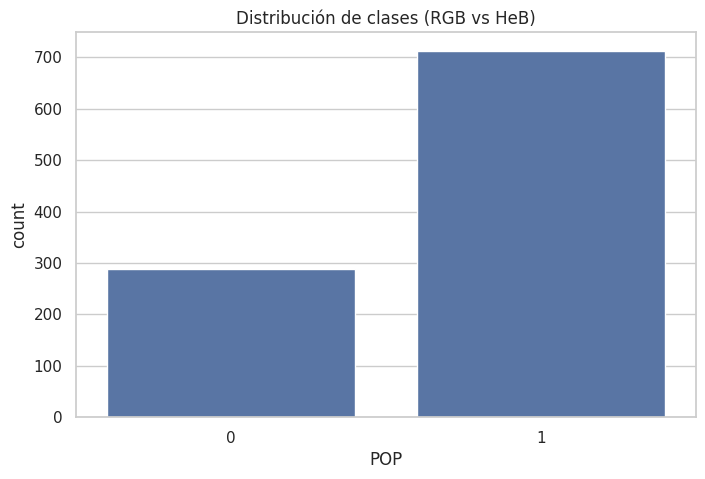

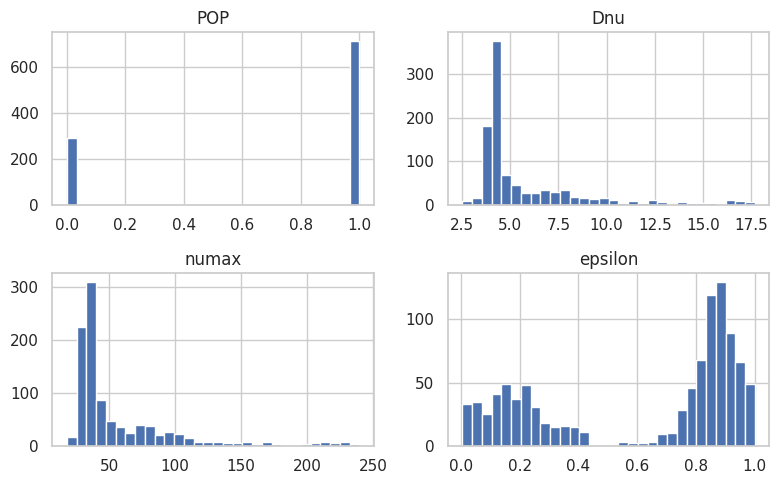

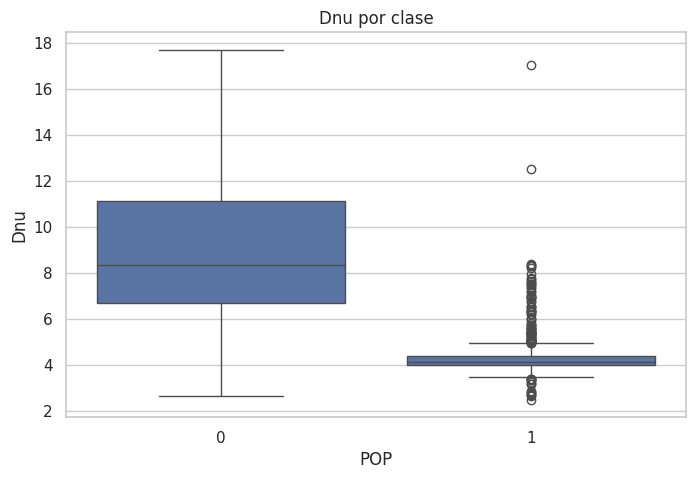

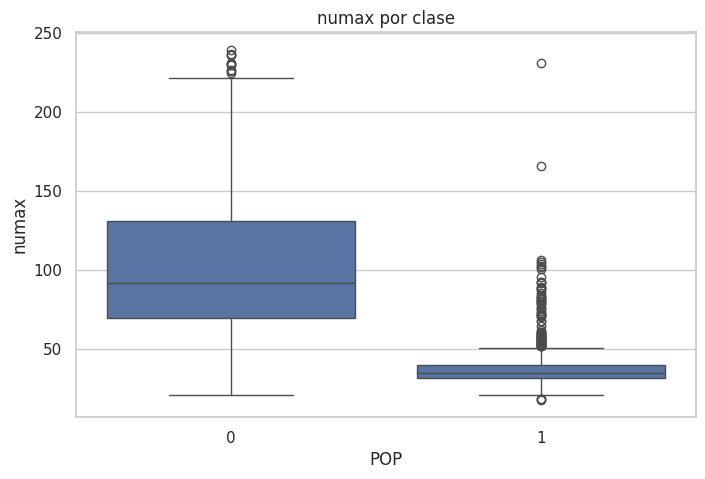

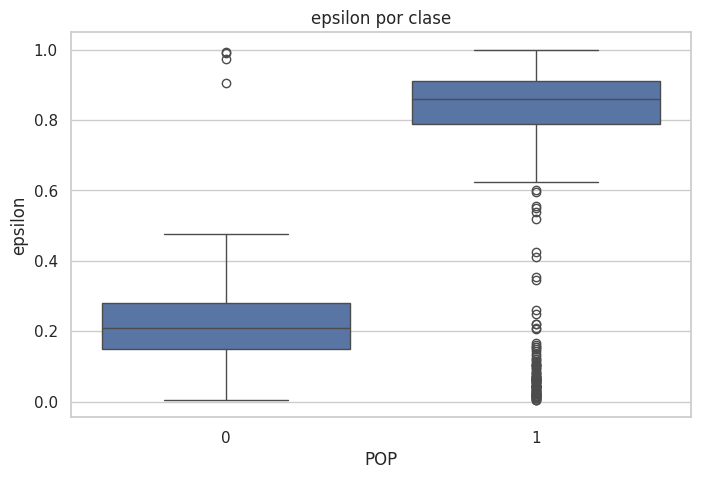

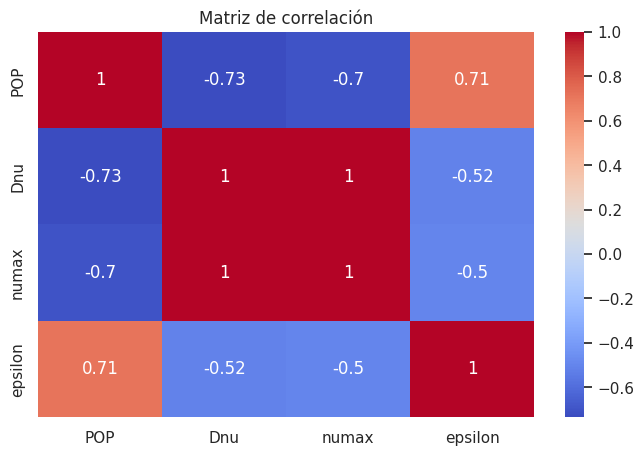

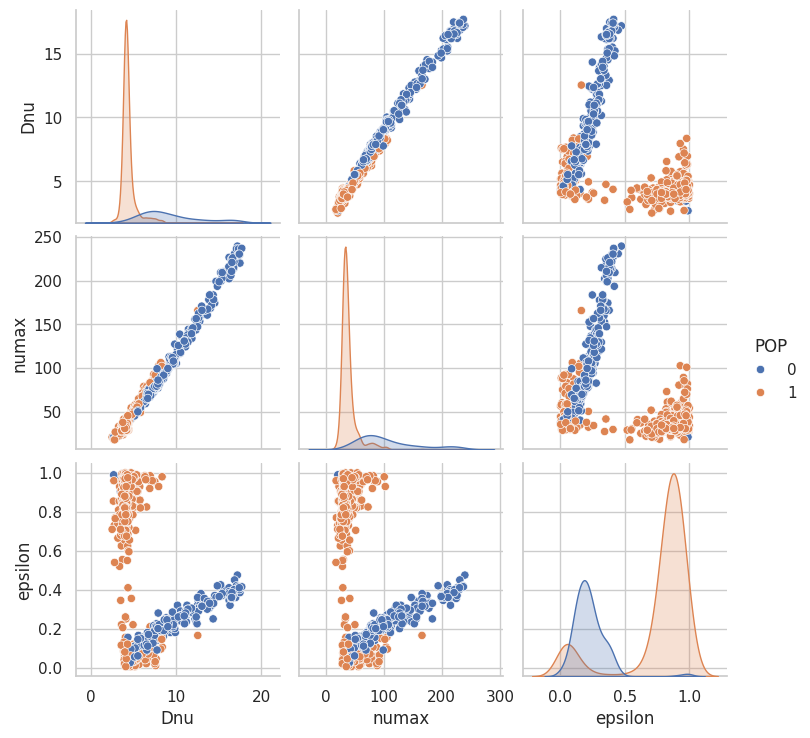

In [ ]:
# ==========================================
# 1. IMPORTACIÓN DE LIBRERÍAS
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

# ==========================================
# 2. CARGA DE DATOS
# ==========================================
df = pd.read_csv("asteroseismology.csv")

# ==========================================
# 3. INSPECCIÓN INICIAL
# ==========================================
print(df.head())
print(df.info())
print(df.describe())

# ==========================================
# 4. CHECK DE NULOS
# ==========================================
print(df.isnull().sum())

# ==========================================
# 5. DISTRIBUCIÓN DE CLASES
# ==========================================
sns.countplot(x='POP', data=df)
plt.title("Distribución de clases (RGB vs HeB)")
plt.show()

# ==========================================
# 6. HISTOGRAMAS
# ==========================================
df.hist(bins=30)
plt.tight_layout()
plt.show()

# ==========================================
# 7. BOXPLOTS POR CLASE
# ==========================================
for col in ['Dnu', 'numax', 'epsilon']:
    sns.boxplot(x='POP', y=col, data=df)
    plt.title(f"{col} por clase")
    plt.show()

# ==========================================
# 8. CORRELACIONES
# ==========================================
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Matriz de correlación")
plt.show()

# ==========================================
# 9. SCATTER PAIRPLOT
# ==========================================
sns.pairplot(df, hue='POP')
plt.show()

#Conclusión1.
hay desbalance de clases, alta correlación por

Accuracy: 0.9850746268656716

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.98      0.97      0.97        58
           1       0.99      0.99      0.99       143

    accuracy                           0.99       201
   macro avg       0.98      0.98      0.98       201
weighted avg       0.99      0.99      0.99       201



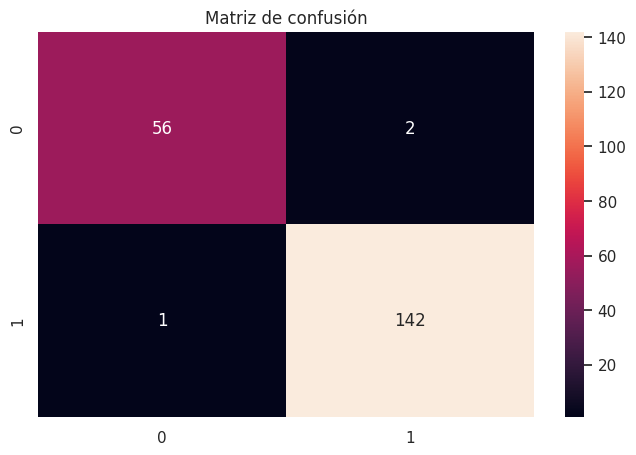

In [ ]:
# ==========================================
# 1. PREPARACIÓN DE DATOS
# ==========================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df[['Dnu', 'numax', 'epsilon']]
y = df['POP']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
#stratify=y es para Corregir desbalance (en caso que exista, primero validar)

# ==========================================
# 2. ESCALADO
# ==========================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# 3. MODELO
# ==========================================
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train_scaled, y_train)

# ==========================================
# 4. EVALUACIÓN
# ==========================================
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title("Matriz de confusión")
plt.show()

# Conclusion2.

In [ ]:
# ==========================================
# FUNCIÓN DE PREDICCIÓN
# ==========================================
def clasificar_gigante_rojo(dnu, numax, epsilon):
    """
    Clasifica un gigante rojo en RGB (0) o HeB (1)

    Parámetros:
    dnu (float): Delta-nu
    numax (float): Frecuencia máxima
    epsilon (float): Posición del modo

    Retorna:
    str: Clase de estrella
    """

    # Crear DataFrame
    data = pd.DataFrame([[dnu, numax, epsilon]],
                        columns=['Dnu', 'numax', 'epsilon'])

    # Escalar
    data_scaled = scaler.transform(data)

    # Predicción
    pred = model.predict(data_scaled)[0]

    if pred == 0:
        return "RGB (Red Giant Branch)"
    else:
        return "HeB (Helium Burning)"

In [ ]:
resultado = clasificar_gigante_rojo(10.5, 120.3, 1.2)
print("Clasificación:", resultado)

Clasificación: HeB (Helium Burning)
